In [ ]:
from spicexplorer.optimization.orchestrator import Circuit_Optimizer_Orchestrator_with_SPICE, Optimizer_Type_Enum
from spicexplorer_core.logging.logger_setup import setup_loggers, setup_loggers_with_spicelib_suppression

from pathlib import Path

logger = setup_loggers_with_spicelib_suppression()
# logger = setup_loggers()

## Comparison to Manual Design of 5t OTA
From JKU IIC github page. Available [here](https://github.com/iic-jku/analog-circuit-design).

## Target to beat: Noise
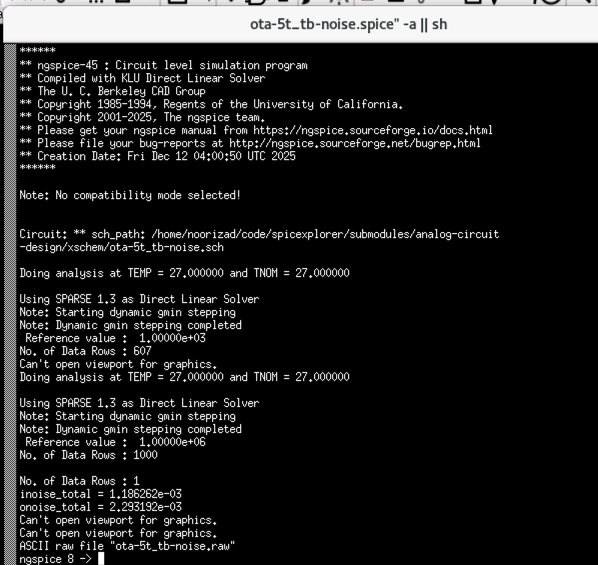

## Target to beat: AC openloop
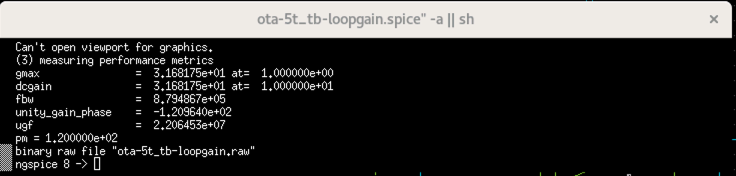

## Target to beat: AC Unity Gain Feedback Mode
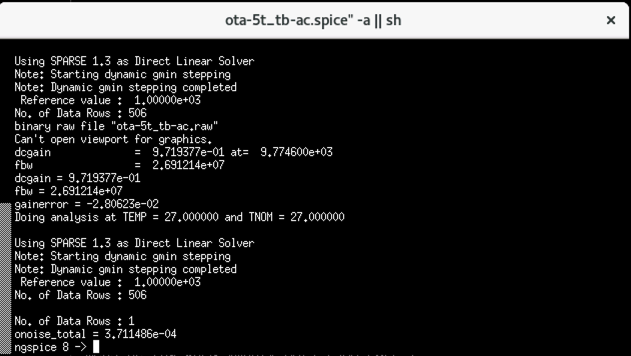


## Target to beat: Transient
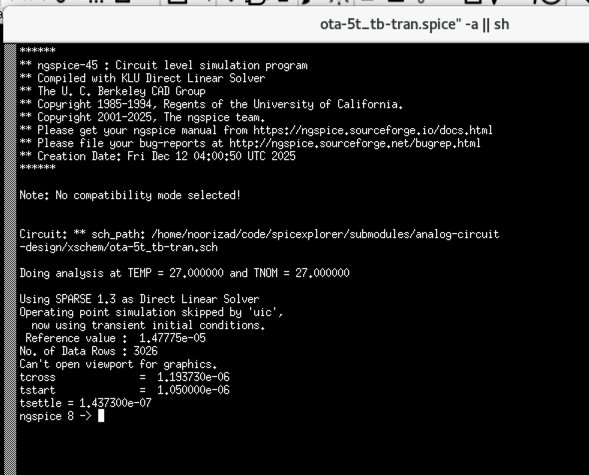

# Start of Optimization Code

In [ ]:
path_to_project_setup = Path("./project_setup.yaml")
optimizer_type = Optimizer_Type_Enum.NEVERGRAD_CONSTRAINT

In [ ]:
orchestrator = Circuit_Optimizer_Orchestrator_with_SPICE(
    project_setup_path=path_to_project_setup,
    optimizer_type=optimizer_type,
    verbose=True
)

In [ ]:
optimizer = orchestrator.get_optimizer()

In [ ]:
# orchestrator.run_sanity_on_spicelib_wrapper()

In [ ]:
optimizer.parameterize()

In [ ]:
optimizer.optimize()

## Viewing the Optimization Results

In [ ]:
optimizer.plot_score(show=True)

In [ ]:
optimizer.plot_optimization_trace(metric_x="ugf", metric_y="dcgain", show=True, save_path="./ugf_dcgain.html")
optimizer.plot_optimization_trace(metric_x="ugf", metric_y="v(inoise_total)", show=True, save_path="./ugf_inoise.html")
optimizer.plot_optimization_trace(metric_x="dcgain", metric_y="v(inoise_total)", show=True,  save_path="./dcgain_inoise.html")
optimizer.plot_optimization_trace(metric_x="ugf", metric_y="pm", show=True,  save_path="./ugf_pm.html")
optimizer.plot_optimization_trace(metric_x="ugf", metric_y="tsettle", show=True,  save_path="./ugf_tsettle.html")
optimizer.plot_optimization_trace(metric_x="dcgain", metric_y="tsettle", show=True,  save_path="./dcgain_tsettle.html")
optimizer.plot_optimization_trace(metric_x="pm", metric_y="tsettle", show=True,  save_path="./pm_tsettle.html")

In [ ]:
optimizer.plot_design_space_exploration(param_x="x_dut_nfet_input_w", param_y="x_dut_nfet_input_l", show=True)

In [ ]:
optimizer.save_checkpoint(name=f"{orchestrator.project_setup.optimizer_config.name}_{orchestrator.project_setup.optimizer_config.budget}")

## Cleanup

In [ ]:
# Uncomment the following line to clean up temporary files created during optimization
# optimizer.clean_up()

In [ ]:
import nevergrad as ng

for item in ng.optimizers.registry:
    print(item)